# LangGraph Level 3B — Swarm and Send API

Patterns covered:
1. **Swarm** — agents that hand control over to each other directly with `Command(goto=)`, with no central supervisor
2. **Send API** — fan-out: dispatch items from a list to workers in parallel (map-reduce)

> **Supervisor vs Swarm:** Supervisor = centralized control (the LLM decides). Swarm = decentralized control (each agent decides who gets control next).

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Literal, Annotated, TypedDict
import operator
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command, Send

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

---
## 1. Swarm — decentralized handoffs between agents

**What is it?** Each agent decides who to hand control to using `Command(goto=other_agent)` or `Command(goto=END)`.
There is no central coordinator node — the agents coordinate among themselves.

**When to use it:** When each agent has enough context to decide the next step.
Example: travel planning where each specialist knows when their part is done.

```
Input → [FlightAgent] → if a hotel is needed → [HotelAgent]
                                              → if activities are needed → [ActivitiesAgent]
                                              → if everything is done → END
```

**Difference vs Supervisor:**
- Supervisor: a central LLM decides on every loop
- Swarm: each agent autonomously decides its next step

In [3]:
class HandoffDecision(BaseModel):
    next_agent: Literal["hotel_agent", "activities_agent", "DONE"]
    reasoning: str
    result: str

class FlightDecision(BaseModel):
    next_agent: Literal["hotel_agent", "DONE"]
    reasoning: str
    flight_info: str

class TravelState(MessagesState):
    destination: str
    budget: str
    flights: str
    hotel: str
    activities: str
    travel_plan: str

flight_llm = llm.with_structured_output(FlightDecision)
handoff_llm = llm.with_structured_output(HandoffDecision)

In [4]:
def flight_agent(state: TravelState) -> Command[Literal["hotel_agent", "__end__"]]:
    """Looks up flights and decides whether a hotel is needed or it can finish."""
    decision = flight_llm.invoke([
        SystemMessage(content=(
            "You are a flights agent. "
            "1) Provide concise flight info for the given destination. "
            "2) If the trip needs accommodation (>1 day) → next_agent='hotel_agent'. "
            "3) If it's a single day with no accommodation → next_agent='DONE'."
        )),
        HumanMessage(content=f"Destination: {state['destination']} | Budget: {state['budget']}")
    ])
    
    print(f"[FlightAgent] → {decision.next_agent} | {decision.reasoning}")
    goto = END if decision.next_agent == "DONE" else decision.next_agent
    
    return Command(
        update={
            "flights": decision.flight_info,
            "messages": [AIMessage(content=f"[Flights] {decision.flight_info}")]
        },
        goto=goto
    )

def hotel_agent(state: TravelState) -> Command[Literal["activities_agent", "__end__"]]:
    """Looks up a hotel and decides whether the activities agent is needed."""
    decision = handoff_llm.invoke([
        SystemMessage(content=(
            "You are a hotels agent. "
            "1) Recommend a specific hotel for the destination and budget. "
            "2) If it's a leisure/tourism trip → next_agent='activities_agent'. "
            "3) If it's a business trip (meetings only) → next_agent='DONE'."
        )),
        HumanMessage(content=f"Destination: {state['destination']} | Budget: {state['budget']} | Flights: {state['flights']}")
    ])
    
    print(f"[HotelAgent] → {decision.next_agent} | {decision.reasoning}")
    goto = END if decision.next_agent == "DONE" else decision.next_agent
    
    return Command(
        update={
            "hotel": decision.result,
            "messages": [AIMessage(content=f"[Hotel] {decision.result}")]
        },
        goto=goto
    )

def activities_agent(state: TravelState) -> Command[Literal["__end__"]]:
    """Suggests activities and produces the full final plan."""
    response = llm.invoke([
        SystemMessage(content="You are a tourism expert. Suggest 3 activities and produce a summary of the full plan."),
        HumanMessage(content=(
            f"Destination: {state['destination']}\n"
            f"Flights: {state['flights']}\n"
            f"Hotel: {state['hotel']}\n"
            f"Budget: {state['budget']}"
        ))
    ])
    
    plan = f"TRAVEL PLAN — {state['destination']}\n\nFlights: {state['flights']}\nHotel: {state['hotel']}\nActivities: {response.content}"
    print(f"[ActivitiesAgent] → END | Full plan generated")
    
    return Command(
        update={
            "activities": response.content,
            "travel_plan": plan,
            "messages": [AIMessage(content=plan)]
        },
        goto=END
    )

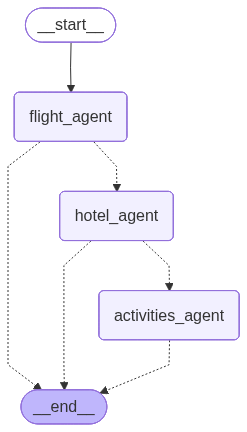

In [5]:
builder = StateGraph(TravelState)
builder.add_node("flight_agent", flight_agent)
builder.add_node("hotel_agent", hotel_agent)
builder.add_node("activities_agent", activities_agent)

# Always start from flight_agent
builder.add_edge(START, "flight_agent")
# Handoffs live inside each Command — there are no add_conditional_edges here

swarm_graph = builder.compile()
display(Image(swarm_graph.get_graph().draw_mermaid_png()))

In [6]:
# Tourism trip → should go through all 3 agents
result = swarm_graph.invoke({
    "destination": "Tokyo, Japan",
    "budget": "2000 EUR for 5 days"
})

print("\n=== FINAL PLAN ===")
print(result.get("travel_plan", "[Plan not generated — agents finished early]"))
print(f"\nAgents executed (by messages): {len(result['messages'])}")

[FlightAgent] → hotel_agent | The trip to Tokyo is for 5 days, which requires accommodation during the stay.
[HotelAgent] → activities_agent | This is a leisure/tourism trip, since the budget and a 5-day Tokyo itinerary are mentioned, suggesting the traveler wants to explore the city and enjoy tourist activities.
[ActivitiesAgent] → END | Full plan generated

=== FINAL PLAN ===
TRAVEL PLAN — Tokyo, Japan

Flights: Direct flight to Tokyo from Madrid. Departure November 1st at 12:00, arrival at 6:00 on November 2nd. Approximate price: 800 EUR round trip.
Hotel: I recommend Hotel Gracery Shinjuku, in the heart of Tokyo. The hotel has an excellent location, close to many tourist attractions, and offers comfortable, modern rooms. The price is approximately 150 EUR per night, which fits the total budget of 2000 EUR for 5 days.
Activities: ### Travel Plan to Tokyo, Japan

**Destination:** Tokyo, Japan  
**Dates:** November 1st to November 6th  
**Total Budget:** 2000 EUR  
**Flights:** Direct

---
## 2. Send API — fan-out: process a list in parallel (map-reduce)

**What is it?** `Send` lets you dispatch the same node with different inputs in parallel.
It is LangGraph's map-reduce pattern: fan-out to workers, fan-in with a reducer.

**Difference vs Orchestrator-Worker (N2C):**
- N2C: fixed workers (worker_1, worker_2, worker_3) — number known at design time
- Send API: dynamic workers — the count depends on the size of the runtime list

```
state.items = ["A", "B", "C", "D"]
    ↓ fan_out generates Sends
[worker(A)] [worker(B)] [worker(C)] [worker(D)]  ← parallel
    ↓           ↓           ↓           ↓
    └───────────┴───────────┴───────────┘ reducer add
                    [reduce] → final output
```

In [7]:
# Parent graph state: holds the list and accumulates results
class MapReduceState(TypedDict):
    topics: list[str]
    analyses: Annotated[list[str], operator.add]  # reducer: merges all worker outputs
    final_report: str

# Worker state: receives a single item
class WorkerState(TypedDict):
    topic: str
    analyses: Annotated[list[str], operator.add]  # writes here, merged into the parent

In [8]:
def fan_out(state: MapReduceState) -> list[Send]:
    """MAP: emits one Send per topic → all workers start in parallel."""
    print(f"[fan_out] Distributing {len(state['topics'])} topics to workers")
    return [Send("analyze_topic", {"topic": topic}) for topic in state["topics"]]

def analyze_topic(state: WorkerState) -> WorkerState:
    """WORKER: analyzes a single topic. There are as many of these as items in the list."""
    response = llm.invoke([
        SystemMessage(content="Analyze this topic in exactly 2 sentences: current impact and future trend."),
        HumanMessage(content=state["topic"])
    ])
    print(f"[Worker] Analyzed: {state['topic'][:40]}...")
    # The Annotated[list, operator.add] reducer appends automatically
    return {"analyses": [f"[{state['topic']}] {response.content}"]}

def reduce_results(state: MapReduceState) -> MapReduceState:
    """REDUCE: combines all analyses into a final report."""
    all_analyses = "\n\n".join(state["analyses"])
    response = llm.invoke([
        SystemMessage(content=(
            "You are a senior analyst. Combine these individual analyses into a cohesive executive report. "
            "Identify common patterns and extract 3 strategic conclusions."
        )),
        HumanMessage(content=all_analyses)
    ])
    print(f"[Reduce] Final report generated ({len(state['analyses'])} analyses combined)")
    return {"final_report": response.content}

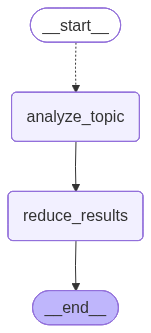

In [9]:
builder = StateGraph(MapReduceState)
builder.add_node("analyze_topic", analyze_topic)
builder.add_node("reduce_results", reduce_results)

# fan_out: function returning list[Send] → activates all workers
builder.add_conditional_edges(START, fan_out, ["analyze_topic"])

# When all workers finish → reduce
builder.add_edge("analyze_topic", "reduce_results")
builder.add_edge("reduce_results", END)

map_reduce_graph = builder.compile()
display(Image(map_reduce_graph.get_graph().draw_mermaid_png()))

In [10]:
ai_topics = [
    "LangGraph and AI agent orchestration",
    "Vector databases in RAG systems",
    "Fine-tuning vs prompting in LLMs",
    "AI Agents in production: real-world challenges",
]

print(f"Processing {len(ai_topics)} topics in parallel...")
result = map_reduce_graph.invoke({"topics": ai_topics})

print("\n=== INDIVIDUAL ANALYSES ===")
for analysis in result["analyses"]:
    print(f"  • {analysis[:120]}...")
    print()

print("=== FINAL REPORT ===")
print(result["final_report"])

Processing 4 topics in parallel...
[fan_out] Distributing 4 topics to workers
[Worker] Analyzed: LangGraph and AI agent orchestration...
[Worker] Analyzed: Vector databases in RAG systems...
[Worker] Analyzed: Fine-tuning vs prompting in LLMs...
[Worker] Analyzed: AI Agents in production: real-world c...
[Reduce] Final report generated (4 analyses combined)

=== INDIVIDUAL ANALYSES ===
  • [LangGraph and AI agent orchestration] LangGraph is reshaping the orchestration of AI agents by enabling more efficient...

  • [Vector databases in RAG systems] Vector databases in Retrieval-Augmented Generation systems are changing how large volumes...

  • [Fine-tuning vs prompting in LLMs] Fine-tuning lets you adapt language models to specific tasks, improving their accuracy...

  • [AI Agents in production: real-world challenges] The current impact of AI Agents in production shows up in process opt...

=== FINAL REPORT ===
### Executive Report: AI Trends Analysis

#### Introduction
This report c

In [ ]:
# The number of workers is dynamic — it works with any number of topics
result_small = map_reduce_graph.invoke({
    "topics": ["Python async programming"]
})
print(f"1 topic → {len(result_small['analyses'])} analyses")

result_large = map_reduce_graph.invoke({
    "topics": ["FastAPI", "Docker", "PostgreSQL", "Redis", "Nginx", "CI/CD"]
})
print(f"6 topics → {len(result_large['analyses'])} analyses")

---
## Swarm vs Supervisor vs Send API

| | Supervisor | Swarm | Send API |
|---|---|---|---|
| **Control** | Centralized (LLM decides) | Decentralized (agents decide) | Deterministic (automatic fan-out) |
| **Workers** | Fixed, in a loop | Variable, calling each other | Dynamic (one per item) |
| **State** | Shared MessagesState | MessagesState + specific keys | `operator.add` reducer for merge |
| **When** | Complex problem with several steps | Each agent knows what to do next | List of items to process in parallel |
| **Risk** | Infinite loop (→ max_steps) | Cycles between agents | Cost grows linearly with item count |

**Next:** `N3C_long_term_memory.ipynb` — `Store`: shared memory across users and sessions